In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
# from matplotlib.colors import LinearSegmentedColormap
# colors_list = ['#f7fbfe', '#83b5d6', '#4895c5', '#bbdda1', '#fbedac', '#f9b27a', '#db484f']
# cmap2 = LinearSegmentedColormap.from_list('custom', colors_list, N=256)

savF = True

In [2]:
import imageio.v2 as imageio
from pathlib import Path
import os

class FigureSaver:
    def __init__(self, base_path, subfolder_name):
        self.base_path = Path(base_path) / subfolder_name
        self.base_path.mkdir(parents=True, exist_ok=True)

    def save_figure(self, fig, filename):
        fig.savefig(self.base_path / f"{filename}.png", dpi=150)
        plt.close(fig)

    def create_gif(self, gif_name="animation"):
        gif_dir = self.base_path.parent / "gif"
        gif_dir.mkdir(parents=True, exist_ok=True)

        images = []
        png_files = sorted(self.base_path.glob("*.png"), key=lambda f: float(f.stem))
        for file in png_files:
            images.append(imageio.imread(file))

        gif_path = gif_dir / f"{gif_name}.gif"
        imageio.mimsave(gif_path, images, duration=0.2, loop=0)
        print(f"Saved {gif_path}")

    def create_video(self, video_name="animation"):
        gif_dir = self.base_path.parent / "gif"
        gif_dir.mkdir(parents=True, exist_ok=True)

        png_files = sorted(self.base_path.glob("*.png"), key=lambda f: float(f.stem))
        video_path = gif_dir / f"{video_name}.mp4"

        import imageio
        writer = imageio.get_writer(video_path, fps=5)
        for file in png_files:
            writer.append_data(imageio.imread(file))
        writer.close()
        print(f"Saved {video_path}")

In [ ]:
def make_colorplot(filename, title, vmin=None, vmax=None, save=False):
    h = h5py.File(filename, "r")
    amplitude = np.asarray(h['entry']['data0']['amplitude'])
    frequencyGHz = np.asarray(h['entry']['data0']['frequency'])/1e9
    degree = np.asarray(h['entry']['data0']['angle'])

    amplitude_dB = 20 * np.log10(np.abs(amplitude))  # shape: (angle, freq)

    fig, ax = plt.subplots(figsize=(4.25, 3.5))

    cax = ax.pcolormesh(degree, frequencyGHz, amplitude_dB.T, shading='auto',
                        cmap='ocean', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(cax, ax=ax)
    cbar.set_label(r'$|S_{21}|$ (dB)', labelpad=10, rotation=90)
    cbar.ax.tick_params(width=1.5, length=4, direction='inout')
    cbar.outline.set_linewidth(1.5)

    ax.set_xlabel(r'$\varphi$ (°)', labelpad=10)
    ax.set_ylabel(r'$\mathrm{\omega \: / \: 2\pi}$ (GHz)', labelpad=10)
    ax.set_title(title, fontsize=11)

    ax.tick_params(direction='in', which='both', top=True, right=True,
                   bottom=True, left=True, width=1.15)
    ax.minorticks_on()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()

    if save:
        save_dir = Path("./colorplots")
        save_dir.mkdir(exist_ok=True)
        fig.savefig(save_dir / f"{title.replace(' ', '_').replace('→', 'to')}.png", dpi=300, bbox_inches='tight')
        print(f"Saved {title}")
        
    plt.show()

## Experimental Data
Feedback Port 4 to Port 3

In [4]:
sweep_filenames = [
    "TARB0B_2D_angle.h5", # SLIDE 48
    "TARC9F_2D_angle.h5", # SLIDE 49
    "TAREZS_2D_angle.h5", # SLIDE 50 
    "TARFT3_2D_angle.h5", # SLIDE 51
]
# output_name = "port4_to_port3"
# title = "Feedback Port 4 → Port 3"

Saved Feedback Port 4 → Port 3


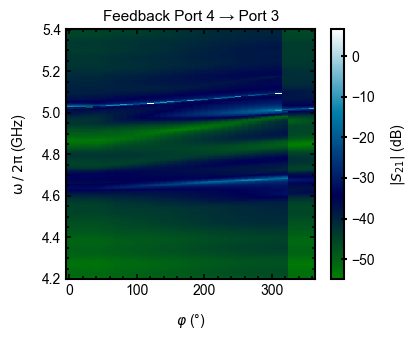

Saved Feedback Port 3 → Port 4


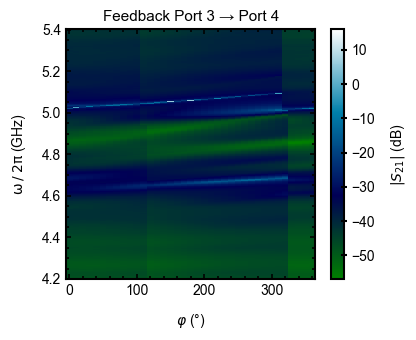

Saved Feedback Port 1 → Port 4


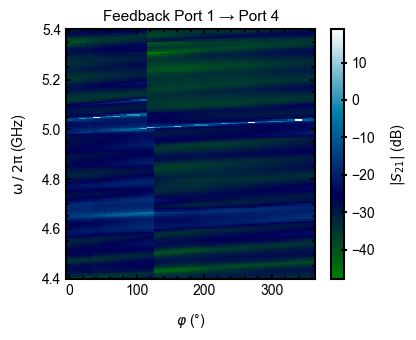

Saved Feedback Port 1 → Port 3


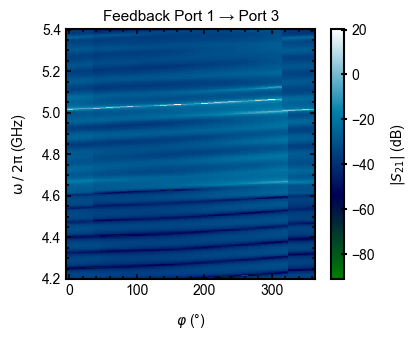

In [5]:
make_colorplot(sweep_filenames[0], "Feedback Port 4 → Port 3", save=True)
make_colorplot(sweep_filenames[1], "Feedback Port 3 → Port 4", save=True)
make_colorplot(sweep_filenames[2], "Feedback Port 1 → Port 4", save=True)
make_colorplot(sweep_filenames[3], "Feedback Port 1 → Port 3", save=True)

In [6]:
# Load base trace
h_base = h5py.File("no-attenuator.h5", "r")
amplitude_base = np.asarray(h_base['entry']['data0']['amplitude'])
frequencyGHz_base = np.asarray(h_base['entry']['data0']['frequency'])/1e9
amplitude_dB_base = 20 * np.log10(np.abs(amplitude_base))

def make_gif(filename, output_name, title):
    h = h5py.File(filename, "r")
    amplitude = np.asarray(h['entry']['data0']['amplitude'])
    frequencyGHz = np.asarray(h['entry']['data0']['frequency'])/1e9
    degree = np.asarray(h['entry']['data0']['angle'])
    
    saver = FigureSaver(".", output_name)
    
    for j in range(len(amplitude)):
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.plot(frequencyGHz_base, amplitude_dB_base, color='seagreen', linewidth=2,
                linestyle='--', label='No Feedback')
        amplitude_dB = 20 * np.log10(np.abs(amplitude[j]))
        ax.plot(frequencyGHz, amplitude_dB, color='tab:purple', linewidth=2,
                label=rf'$\varphi$ = {degree[j]:.2f}°')
        ax.set_xlabel(r'$\mathrm{\omega \: / \: 2\pi}$ (GHz)', labelpad=10)
        ax.set_ylabel(r'$|S_{21}|$ (dB)', labelpad=10)
        ax.set_ylim(-60, 0)
        ax.set_title(title, fontsize=11)
        ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(direction='in', which='both', top=True, right=True,
                       bottom=True, left=True, width=1.15)
        ax.minorticks_on()
        ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
        ax.legend(loc='upper left')
        plt.tight_layout()
        saver.save_figure(fig, j)
    
    saver.create_gif(output_name)

In [7]:
make_gif(sweep_filenames[0],"port4_to_port3","Feedback Port 4 → Port 3")
make_gif(sweep_filenames[1],"port3_to_port4","Feedback Port 3 → Port 4")
make_gif(sweep_filenames[2],"port1_to_port4","Feedback Port 1 → Port 4")
make_gif(sweep_filenames[3],"port1_to_port3","Feedback Port 1 → Port 3")

Saved gif/port4_to_port3.gif
Saved gif/port3_to_port4.gif
Saved gif/port1_to_port4.gif
Saved gif/port1_to_port3.gif
